<a href="https://colab.research.google.com/github/ProjetosNanos/NanoAgenteSimples/blob/main/NanoAgentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import langgraph
import numpy as np
import pandas as pd

In [18]:
# 1. Instala Ollama
!curl -fsSL https://ollama.com/install.sh | sh

# 2. Inicia servidor Ollama server em background
!nohup ollama serve > /dev/null 2>&1 &

# 3. Faz download do modelo
!ollama pull gpt-oss:20b

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.



In [19]:
!pip install langchain -q
!pip install langchain-core -q
!pip install langchain-community -q
!pip install langchain-ollama -q
!pip install langgraph -q

In [20]:
from langchain_community.llms import Ollama

def processamento_resposta(pergunta):
  # Initialize the Ollama LLM
  llm = Ollama(model="gpt-oss:20b",num_predict=1024)

  # Send a prompt
  resposta = llm.invoke(pergunta)
  return resposta

processamento_resposta("Diga: Hello World!")

ValueError: Ollama call failed with status code 500. Details: {"error":"model requires more system memory (13.1 GiB) than is available (12.0 GiB)"}

In [21]:
from langgraph.graph import StateGraph, START, END
from langchain_community.llms import Ollama
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage


# Definir o esquema de estado
class State(TypedDict):
     messages: Annotated[list[str], add_messages]

 # Inicializar o modelo Ollama
llm = Ollama(model="gpt-oss:20b", num_predict=1024)

 # Definir a função do nó de entrada
def entrada_usuario(state: State) -> State:
    pergunta = input("Pergunta: ")
    return {"messages": [pergunta]}

 # Definir a função do nó de processamento
def processamento_resposta(state: State) -> State:
    pergunta = state["messages"][-1]
    resposta = llm.invoke(pergunta)
    return {"messages": [f"A resposta para a sua pergunta '{pergunta}' é: {resposta}"]}

 # Definir a função do nó de saída
def saida_resposta(state: State) -> State:
    print(state["messages"][-1])
    return state



def processamento_resposta(state: State) -> State:
    pergunta = state["messages"][-1]
    if isinstance(pergunta, str) and pergunta.strip():
        resposta = llm.invoke(pergunta)
        return {"messages": [f"A resposta para a sua pergunta '{pergunta}' é: {resposta}"]}
    else:
        raise ValueError("A pergunta deve ser uma string não vazia.")


 # Criar o grafo de estado
grafo = StateGraph(State)

 # Adicionar nós ao grafo
grafo.add_node("entrada", entrada_usuario)
grafo.add_node("processamento", processamento_resposta)
grafo.add_node("saida", saida_resposta)

 # Definir as conexões entre os nós
grafo.add_edge(START, "entrada")
grafo.add_edge("entrada", "processamento")
grafo.add_edge("processamento", "saida")
grafo.add_edge("saida", END)

 # Compilar o grafo
compiled = grafo.compile()

 # Implementar ciclo de interação
while True:
    compiled.invoke({"messages": [""]})
    continuar = input("Você deseja fazer outra pergunta? (sim/não): ")
    if continuar.lower() != 'sim':
        break

Pergunta: oba baum


ValueError: A pergunta deve ser uma string não vazia.

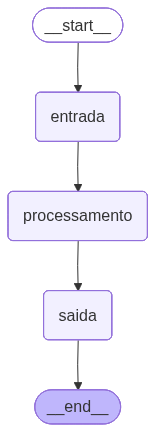

In [6]:
from IPython.display import Image

Image(compiled.get_graph().draw_mermaid_png())